In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset

In [ ]:
_df = {
    'train': pd.read_json('../data/train.json', orient='index'),
    'dev': pd.read_json('../data/dev.json', orient='index'),
    'test': pd.read_json('../data/test.json', orient='index')
}
df = pd.concat([_df['train'], _df['dev'], _df['test']], ignore_index=True)

In [5]:
df

,review,label,domain
0,gói hàng cẩn thận . chơi pubg với lie...,non-complaint,mobile
1,mình góp ý thật nhé . . đừng bắt pha...,complaint,app
2,"máy khá đẹp , pin trâu vân tay nhạy nhạ...",complaint,mobile
3,một mớ lỗi : không xem lại được bà...,complaint,app
4,đặc mẫu xanh mà sao giao mẫu này vậy...,complaint,fashion
...,...,...,...
5479,đẹp hơn mong đợi . tuy nhiên một lỗi ...,complaint,fashion
5480,chính hãng xài thích,non-complaint,cosmetic
5481,đồ rất đẹp,non-complaint,fashion
5482,đỡ hơn sau một tháng sử dụng,non-complaint,cosmetic


# EDA

## 2.1. `review` column

In [6]:
def count_words(input: str) -> int:
    return len(input.split())

In [7]:
word_counts = df['review'].apply(count_words)

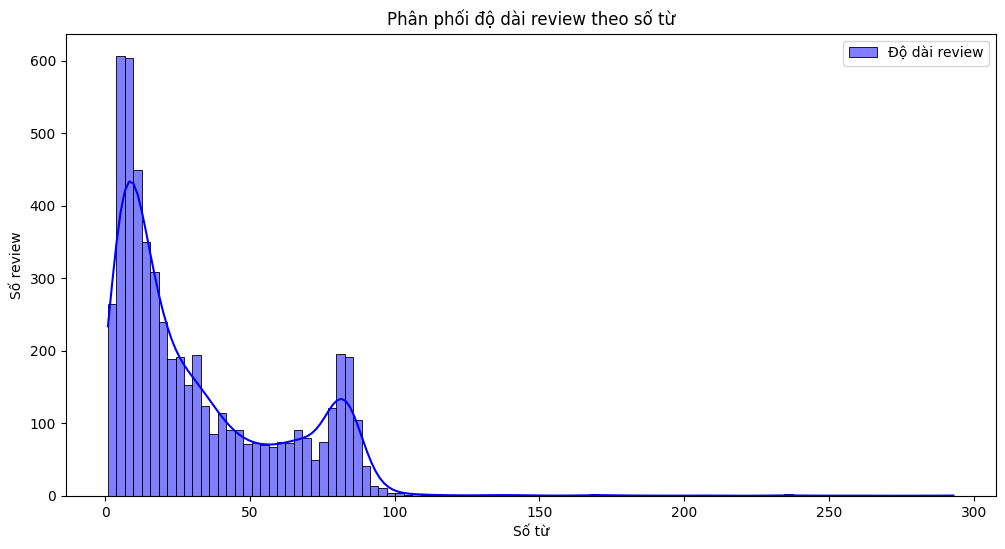

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(word_counts, bins=100, kde=True, color='blue', label='Độ dài review')

plt.title('Phân phối độ dài review theo số từ')
plt.xlabel('Số từ')
plt.ylabel('Số review')
plt.legend()
plt.savefig('./img/word_count_distribution.png')

## 1.2. `label`

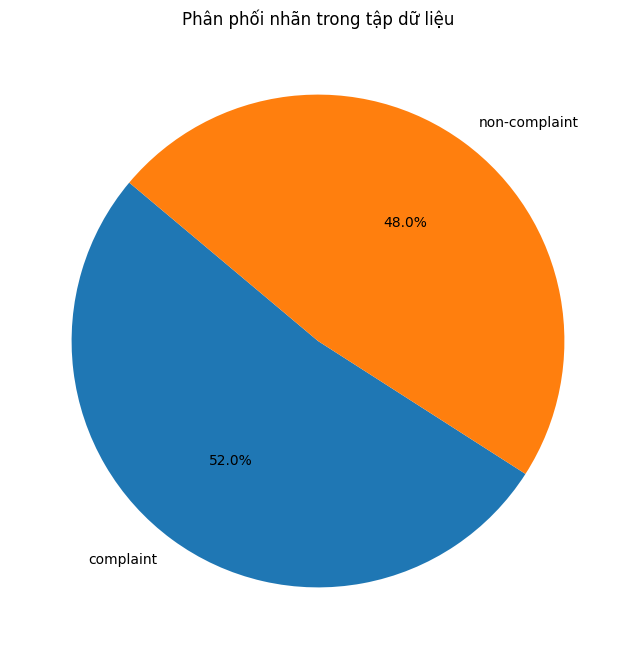

In [16]:
labels = df['label'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(labels, labels=labels.index, autopct='%1.1f%%', startangle=140)
plt.title('Phân phối nhãn trong tập dữ liệu')
plt.savefig('./img/label_distribution.png')

## 2.3. `domain`

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_9172\46145803.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.index, y=domain_counts.values, palette='viridis')


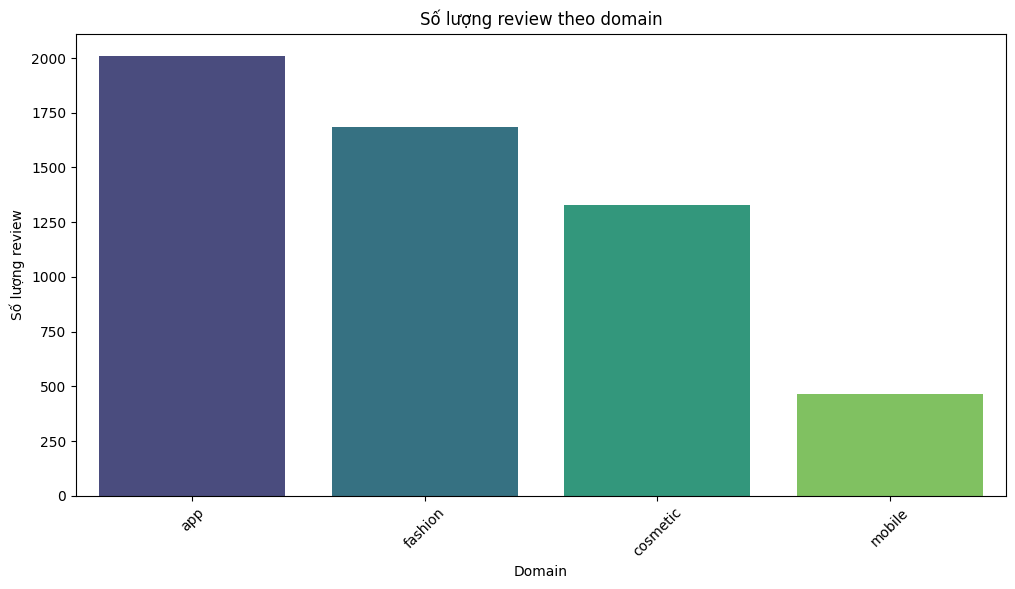

In [17]:
domain_counts = df['domain'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=domain_counts.index, y=domain_counts.values, palette='viridis')
plt.title('Số lượng review theo domain')
plt.xlabel('Domain')
plt.ylabel('Số lượng review')
plt.xticks(rotation=45)
plt.savefig('./img/domain_distribution.png')